In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
import seaborn as sns
import sklearn
import tensorflow as tf
from tensorflow.keras import models
import tensorflow.keras.layers as tfl
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import BatchNormalization

data_path = '/content/drive/MyDrive/Colab Notebooks/data/train'
class_names = os.listdir(data_path)
print(class_names)

import cv2
import os
import numpy as np
import sklearn.model_selection
from tensorflow.keras.utils import to_categorical # Thêm import này
from tensorflow.keras.applications.resnet50 import preprocess_input

X = []
y = []

for label, name in enumerate(class_names):
    folder_path = os.path.join(data_path, name)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Đọc ảnh
        img = cv2.imread(img_path)
        if img is None: continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (224, 224))
        img = img.astype('float32')

        X.append(img)
        y.append(label)

X = np.array(X)
X = preprocess_input(X)
y = np.array(y)



y = to_categorical(y, num_classes=len(class_names))

print("X shape và dtype:", X.shape, X.dtype)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    zoom_range = 0.15 ,
    rotation_range = 10 ,
    width_shift_range = 0.1 ,
    height_shift_range = 0.1 ,
    fill_mode = 'nearest'
)

test_datagen = ImageDataGenerator(
)

# fit chỉ cần cho train_datagen nếu sử dụng các phép biến đổi cần tính toán thống kê từ dữ liệu
train_datagen.fit(X_train)

print("Đã thiết lập Data Augmentation mới.")

['Acral_Lentiginous_Melanoma', 'pitting', 'blue_finger', 'Onychogryphosis', 'clubbing', 'Healthy_Nail']
X shape và dtype: (4178, 224, 224, 3) float32
y shape: (4178, 6)
Đã thiết lập Data Augmentation mới.


In [3]:
def Build_ResNet50(input_shape=(224, 224, 3), classes=6):
    X_input = Input(input_shape)

    # 1. Load ResNet50 with ImageNet weights
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights='imagenet',
        input_tensor=X_input
    )

    # 2. Freeze the layers of the base model
    base_model.trainable = False

    # Add the classifier head
    X = base_model.output
    X = GlobalAveragePooling2D()(X)
    X = Dropout(0.5)(X)
    X = Dense(classes, activation='softmax', kernel_initializer=glorot_uniform(seed=0))(X)

    model = Model(inputs=X_input, outputs=X, name='ResNet50_Transfer_Model')
    return model

In [4]:
# Create an instance of the ResNet50 model and display its detailed structure
resnet_model = Build_ResNet50(input_shape=(224, 224, 3), classes=len(class_names))
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Transfer_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', # hoặc 'sparse_categorical_crossentropy' tùy cách bạn làm label
    metrics=['accuracy']
)

In [6]:
epochs = 10 # You can adjust the number of epochs
batch_size = 32

history = resnet_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True),
    validation_data=test_datagen.flow(X_test, y_test, batch_size=batch_size),
    epochs=epochs,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
    ]
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 521ms/step - accuracy: 0.5311 - loss: 1.3460 - val_accuracy: 0.7691 - val_loss: 0.6168 - learning_rate: 0.0010
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 42s 399ms/step - accuracy: 0.7232 - loss: 0.7450 - val_accuracy: 0.8122 - val_loss: 0.5210 - learning_rate: 0.0010
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 45s 431ms/step - accuracy: 0.7735 - loss: 0.6260 - val_accuracy: 0.8337 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 459ms/step - accuracy: 0.8094 - loss: 0.5241 - val_accuracy: 0.8469 - val_loss: 0.4172 - learning_rate: 0.0010
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 436ms/step - accuracy: 0.8103 - loss: 0.5066 - val_accuracy: 0.8481 - val_loss: 0.4101 - learning_rate: 0.0010
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 44s 417ms/step - accuracy: 0.8211 - loss: 0.4608 - val_accuracy: 0.8565 - val_loss: 0.3906 - learning_rate: 0.0010
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 44s 422ms/step - accuracy: 0.8

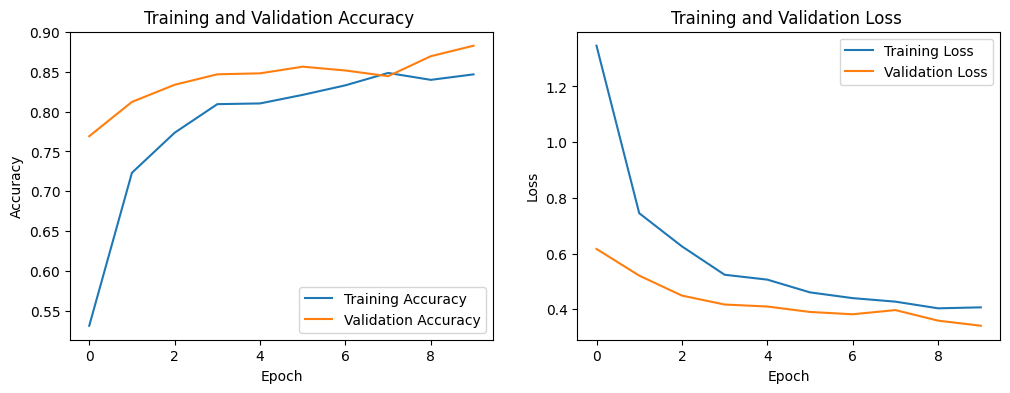

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy ')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
# Lưu mô hình
model_save_path = '/content/ResNet50FingerNails.h5'
resnet_model.save(model_save_path)
print(f"Mô hình đã được lưu tại: {model_save_path}")

Mô hình đã được lưu tại: /content/ResNet50FingerNails.h5


In [10]:
from tensorflow.keras.models import load_model

# Tải lại mô hình từ đường dẫn đã lưu
loaded_model = load_model(model_save_path)
print("Mô hình đã được tải lại thành công!")

Mô hình đã được tải lại thành công!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Hình ảnh mẫu có chỉ số: 620
Nhãn thực tế: Onychogryphosis (index: 3)
Dự đoán của mô hình: Onychogryphosis (index: 3)
Xác suất dự đoán: 0.9944


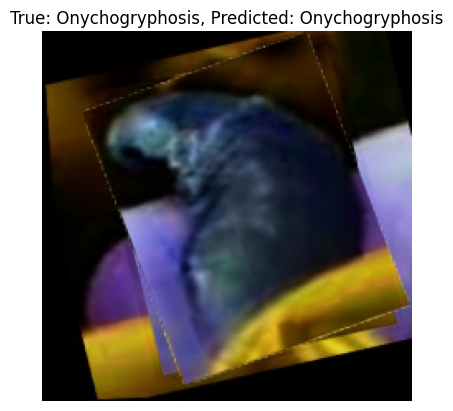

In [24]:
from tensorflow.keras.models import load_model

# Chọn một hình ảnh ngẫu nhiên từ tập kiểm tra để dự đoán
import numpy as np
import matplotlib.pyplot as plt

sample_index = np.random.randint(0, len(X_test))
sample_image = X_test[sample_index]
sample_true_label = np.argmax(y_test[sample_index])

# Reshape hình ảnh để phù hợp với input của mô hình (thêm batch dimension)
sample_image_batch = np.expand_dims(sample_image, axis=0)

# Thực hiện dự đoán
predictions = loaded_model.predict(sample_image_batch)
predicted_class_index = np.argmax(predictions[0])

print(f"Hình ảnh mẫu có chỉ số: {sample_index}")
print(f"Nhãn thực tế: {class_names[sample_true_label]} (index: {sample_true_label})")
print(f"Dự đoán của mô hình: {class_names[predicted_class_index]} (index: {predicted_class_index})")
print(f"Xác suất dự đoán: {predictions[0][predicted_class_index]:.4f}")

# Hiển thị hình ảnh
# Hoàn tác quá trình preprocess_input để hiển thị hình ảnh đúng cách
# Đối với ResNet50 của Keras, preprocess_input thường trừ đi giá trị trung bình
# Để hiển thị, ta cần cộng lại giá trị trung bình đó.
# Giá trị trung bình điển hình cho ImageNet (RGB) là [103.939, 116.779, 123.68] nếu ở chế độ 'caffe' hoặc scaling nếu ở chế độ 'tf'.
# Dựa trên cảnh báo '[-123.68..133.22101]', có vẻ là chế độ 'caffe' đã được sử dụng (chỉ trừ mean).

display_image = sample_image.copy() # Tạo bản sao để không ảnh hưởng đến dữ liệu gốc
display_image[:, :, 0] += 103.939
display_image[:, :, 1] += 116.779
display_image[:, :, 2] += 123.68

# Clip giá trị pixel về dải 0-255 và chuyển sang kiểu int (uint8)
display_image = np.clip(display_image, 0, 255).astype('uint8')

plt.imshow(display_image)
plt.title(f"True: {class_names[sample_true_label]}, Predicted: {class_names[predicted_class_index]}")
plt.axis('off')
plt.show()

In [17]:
# Sử dụng test_datagen.flow để đảm bảo tiền xử lý nhất quán với tập huấn luyện
test_loss, test_accuracy = resnet_model.evaluate(test_datagen.flow(X_test, y_test, batch_size=32, shuffle=False))
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8828 - loss: 0.3412
Test loss: 0.3412
Test accuracy: 0.8828
